In [19]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Генерируем реалистичные данные
np.random.seed(42)

# Создаем 500 пользователей с разными датами регистрации
user_ids = range(1, 501)
reg_dates = [datetime(2023, 9, 1) + timedelta(days=np.random.randint(0, 90)) for _ in user_ids]

# Создаем таблицу регистраций
registrations = pd.DataFrame({
    'user_id': user_ids,
    'event_date': reg_dates,
    'event_type': 'registration'
})

# Генерируем события входов (не все пользователи возвращаются)
logins = []
for user_id, reg_date in zip(user_ids, reg_dates):
    # Вероятность возврата уменьшается со временем
    for days_after in [1, 7, 14, 30]:
        if np.random.random() < 0.7 - (days_after * 0.015):  # 70% на 1-й день, 25% на 30-й
            login_date = reg_date + timedelta(days=days_after)
            logins.append({
                'user_id': user_id,
                'event_date': login_date,
                'event_type': 'login'
            })

# Объединяем регистрации и входы
df_events = pd.concat([registrations, pd.DataFrame(logins)], ignore_index=True)

# Преобразуем в datetime
df_events['event_date'] = pd.to_datetime(df_events['event_date'])

print("Первые 10 событий:")
display(df_events.head(10))
print(f"\nВсего событий: {len(df_events)}")
print(f"Уникальных пользователей: {df_events['user_id'].nunique()}")
print(f"Пропусков (NaT) в event_date: {df_events['event_date'].isna().sum()}") # Должно быть 0!

Первые 10 событий:


,user_id,event_date,event_type
0,1,2023-10-22,registration
1,2,2023-09-15,registration
2,3,2023-11-11,registration
3,4,2023-10-31,registration
4,5,2023-09-21,registration
5,6,2023-11-22,registration
6,7,2023-11-26,registration
7,8,2023-11-14,registration
8,9,2023-11-14,registration
9,10,2023-11-27,registration



Всего событий: 1520
Уникальных пользователей: 500
Пропусков (NaT) в event_date: 0


In [20]:
#Находим самую раннюю дату (дату регистрации) для каждого пользователя
user_reg_dates = df_events.groupby('user_id')['event_date'].min().reset_index()

#Переименуем колонку для ясности
user_reg_dates = user_reg_dates.rename(columns={'event_date': 'reg_date'})

print("Дата регистрации первых 5 пользователей:")
display(user_reg_dates.head(5))



Дата регистрации первых 5 пользователей:


,user_id,reg_date
0,1,2023-10-22
1,2,2023-09-15
2,3,2023-11-11
3,4,2023-10-31
4,5,2023-09-21


In [21]:
# Объединяем табицы по usr_id
df_cohorts = pd.merge(df_events, user_reg_dates, on='user_id', how='left')

# Считаем разницу в днях между событием и регистрацией
df_cohorts['days_since_reg'] = (df_cohorts['event_date'] - df_cohorts['reg_date']).dt.days

print('Первые 10 событий с расчетом дней:')

display(df_cohorts[['user_id', 'event_type', 'event_date', 'reg_date', 'days_since_reg']].head(10))

#Создаем колонку 'cohort' в формате 'Год-Месяц'
df_cohorts['cohort'] = df_cohorts['reg_date'].dt.to_period('M').astype(str)

print('Добавили когорту')
display(df_cohorts[['user_id','reg_date','cohort', 'days_since_reg']].head(10))


Первые 10 событий с расчетом дней:


,user_id,event_type,event_date,reg_date,days_since_reg
0,1,registration,2023-10-22,2023-10-22,0
1,2,registration,2023-09-15,2023-09-15,0
2,3,registration,2023-11-11,2023-11-11,0
3,4,registration,2023-10-31,2023-10-31,0
4,5,registration,2023-09-21,2023-09-21,0
5,6,registration,2023-11-22,2023-11-22,0
6,7,registration,2023-11-26,2023-11-26,0
7,8,registration,2023-11-14,2023-11-14,0
8,9,registration,2023-11-14,2023-11-14,0
9,10,registration,2023-11-27,2023-11-27,0


Добавили когорту


,user_id,reg_date,cohort,days_since_reg
0,1,2023-10-22,2023-10,0
1,2,2023-09-15,2023-09,0
2,3,2023-11-11,2023-11,0
3,4,2023-10-31,2023-10,0
4,5,2023-09-21,2023-09,0
5,6,2023-11-22,2023-11,0
6,7,2023-11-26,2023-11,0
7,8,2023-11-14,2023-11,0
8,9,2023-11-14,2023-11,0
9,10,2023-11-27,2023-11,0


In [22]:
# Показываем только события login
logins_only = df_cohorts[df_cohorts['event_type']=='login']

print(f"Всего событий login: {len(logins_only)}")
print("\nПервые 10 событий login:")
display(logins_only[['user_id', 'event_date', 'reg_date', 'cohort', 'days_since_reg']].head(10))

Всего событий login: 1020

Первые 10 событий login:


,user_id,event_date,reg_date,cohort,days_since_reg
500,1,2023-10-23,2023-10-22,2023-10,1
501,1,2023-10-29,2023-10-22,2023-10,7
502,1,2023-11-05,2023-10-22,2023-10,14
503,1,2023-11-21,2023-10-22,2023-10,30
504,2,2023-09-16,2023-09-15,2023-09,1
505,2,2023-09-22,2023-09-15,2023-09,7
506,2,2023-09-29,2023-09-15,2023-09,14
507,3,2023-11-12,2023-11-11,2023-11,1
508,3,2023-11-25,2023-11-11,2023-11,14
509,3,2023-12-11,2023-11-11,2023-11,30


In [23]:
# Считаем уникальных пользователей по когортам и дням
cohort_counts = df_cohorts.groupby(['cohort', 'days_since_reg'])['user_id'].nunique().reset_index()

cohort_counts = cohort_counts.rename(columns={'user_id':'user_count'})

print("Количество пользователей по когортам и дням:")
display(cohort_counts)

Количество пользователей по когортам и дням:


,cohort,days_since_reg,user_count
0,2023-09,0,172
1,2023-09,1,119
2,2023-09,7,108
3,2023-09,14,80
4,2023-09,30,36
5,2023-10,0,178
6,2023-10,1,120
7,2023-10,7,107
8,2023-10,14,86
9,2023-10,30,49


In [24]:
# Создаем сводную таблицу
retention_matrix = cohort_counts.pivot(index='cohort', columns='days_since_reg', values='user_count')

print("Матрица удержания (абсолютные числа):")
display(retention_matrix.head())

Матрица удержания (абсолютные числа):


days_since_reg,0,1,7,14,30
cohort,,,,,
2023-09,172,119,108,80,36
2023-10,178,120,107,86,49
2023-11,150,112,86,67,50


In [25]:
# Размер каждой когорты (День 0)
cohort_sizes = retention_matrix[0]


# Делим каждый столбец на размер когорты и умножаем на 100 для процентов
retention_percentage = retention_matrix.divide(cohort_sizes, axis=0) * 100

# Округляем до 1 знака после запятой для красоты
retention_percentage = retention_percentage.round(1)

print("Матрица удержания в процентах (%):")
display(retention_percentage.head())

Матрица удержания в процентах (%):


days_since_reg,0,1,7,14,30
cohort,,,,,
2023-09,100.0,69.2,62.8,46.5,20.9
2023-10,100.0,67.4,60.1,48.3,27.5
2023-11,100.0,74.7,57.3,44.7,33.3


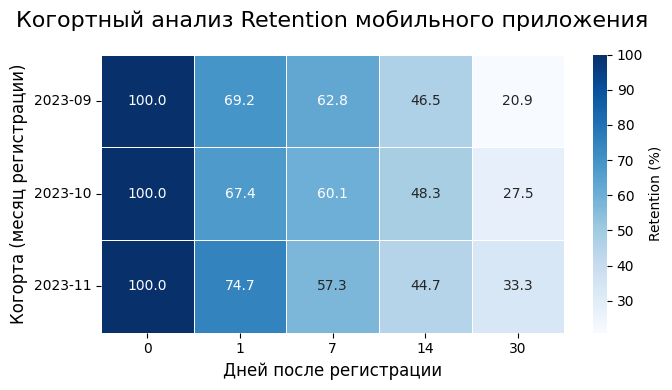

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

#Создаем фигру размером 14х8 дюймов
plt.figure(figsize=(7,4))

#Строим тепловую карту
sns.heatmap(
    retention_percentage,
    annot=True,           #Показываем числа внутри ячеек
    fmt='.1f',            #Формат чисел: 1 знак после запятой
    cmap='Blues',          #Цветовая палитра (синие оттенки)
     linewidths=0.5,       # Толщина разделительных линий
    linecolor='white',    # Цвет линий
    cbar_kws={'label': 'Retention (%)'}  # Подпись цветовой шкалы
)

# Настройки оформления
plt.title('Когортный анализ Retention мобильного приложения', fontsize=16, pad=20)
plt.xlabel('Дней после регистрации', fontsize=12)
plt.ylabel('Когорта (месяц регистрации)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

# Показываем график
plt.savefig('retention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()